In [1]:
######################################################################
## 06_ANALYSIS: Methylation vs. Gene Expression
######################################################################

In [2]:
######################################################################
## 0. Project paths
######################################################################

data_dir    <- "data"
out_fig_dir <- file.path("outputs", "figures")

dir.create(out_fig_dir, recursive = TRUE, showWarnings = FALSE)

# Input files
bsseq_file         <- file.path(data_dir, "bsseq_snp_masked.RData")
gff_file           <- file.path(data_dir, "GCF_021869535.1_genomic.gff")
salmon_quant_file  <- file.path(data_dir, "salmon_quant", "quant.sf")

df_profile_file <- file.path("outputs", "data", "df_profile.rds")
stopifnot(file.exists(df_profile_file))
df_profile <- readRDS(df_profile_file)

stopifnot(
  file.exists(bsseq_file),
  file.exists(gff_file),
  file.exists(salmon_quant_file)
)

In [3]:
######################################################################
## 1: Load libraries
######################################################################

suppressMessages({
  library(bsseq)
  library(rtracklayer)
  library(GenomicRanges)
  library(tidyverse)   # dplyr, tidyr, tibble, stringr, readr, ggplot2, purrr
  library(tximport)
  library(ppcor)
  library(patchwork)
})

In [4]:
######################################################################
## 2: Load Data and Metadata
######################################################################

# Load BSseq object (expects object named BSseq_obj_masked inside the .RData)
load(bsseq_file)
BSseq_obj <- BSseq_obj_masked

# GFF annotation
gff <- import(gff_file)

# Salmon quant import (single quant.sf)
files <- setNames(salmon_quant_file, "sample1")
txi   <- tximport(files, type = "salmon", txOut = TRUE)

# Extract gene-protein mapping from GFF
gff_df <- as.data.frame(gff)
tx2gene <- gff_df %>%
  filter(type == "CDS" & !is.na(protein_id) & !is.na(gene)) %>%
  distinct(protein_id, gene)

reading in files with read_tsv

1 




In [5]:
######################################################################
## 3: Define Genomic Regions
######################################################################

# Take gene features
genes_gr <- gff[gff$type %in% c("gene"), ]

# Build a stable gene identifier: gene -> Name -> ID
gene_id <- dplyr::coalesce(mcols(genes_gr)$gene,
                           mcols(genes_gr)$Name,
                           mcols(genes_gr)$ID)

# Drop rows with no identifier
keep     <- !is.na(gene_id) & gene_id != ""
genes_gr <- genes_gr[keep]
gene_id  <- gene_id[keep]

# Standardize to match downstream tables
gene_id <- paste0("gene-", gene_id)

# Set both a column and the GRanges names (CRITICAL)
genes_gr$gene   <- gene_id
names(genes_gr) <- gene_id

# Regions
# Proximal promoter = 150 bp upstream of the TSS (strand-aware), matching the
# manuscript definition used for the methylation-expression analysis.
gene_bodies    <- genes_gr
prox_promoters <- GenomicRanges::promoters(genes_gr, upstream = 150, downstream = 0)
names(prox_promoters) <- names(genes_gr)

In [6]:
######################################################################
## 4: Calculate Average Methylation per Region
######################################################################

gene_meth <- getMeth(BSseq_obj, regions = gene_bodies, type = "raw", what = "perRegion") %>%
  as.data.frame() %>%
  mutate(gene = names(gene_bodies)) %>%
  relocate(gene)

prox_meth <- getMeth(BSseq_obj, regions = prox_promoters, type = "raw", what = "perRegion") %>%
  as.data.frame() %>%
  mutate(gene = names(prox_promoters)) %>%
  relocate(gene)

In [7]:
######################################################################
## 4.5: Process expression (create expression_gene)
######################################################################

# txi$abundance is a matrix of TPM with transcripts as rownames
expr_long <- as.data.frame(txi$abundance) %>%
  rownames_to_column("tx_id") %>%
  pivot_longer(-tx_id, names_to = "sample", values_to = "tpm")

# A) direct match on protein_id
expr_mapped_A <- expr_long %>%
  left_join(tx2gene, by = c("tx_id" = "protein_id"))

# If most rows didn't map, fall back to XP_ extraction
mapped_frac_A <- mean(!is.na(expr_mapped_A$gene))
if (is.na(mapped_frac_A)) mapped_frac_A <- 0

if (mapped_frac_A < 0.10) {
  expr_mapped <- expr_long %>%
    mutate(protein_id = str_extract(tx_id, "XP_\\d+\\.\\d+")) %>%
    left_join(tx2gene, by = "protein_id")
} else {
  expr_mapped <- expr_mapped_A %>%
    mutate(protein_id = tx_id)
}

# Standardize gene IDs to match methylation tables (gene- prefix)
expr_mapped <- expr_mapped %>%
  mutate(gene = paste0("gene-", gene)) %>%
  filter(!is.na(gene))

# Collapse to gene-level TPM per sample (sum of transcript TPMs)
expression_gene <- expr_mapped %>%
  group_by(gene, sample) %>%
  summarise(tpm = sum(tpm, na.rm = TRUE), .groups = "drop")

# Single RNA-seq sample: keep one gene->tpm table; else average across samples
# NOTE: dplyr::select is namespaced to avoid masking by AnnotationDbi::select (bsseq)
if (dplyr::n_distinct(expression_gene$sample) == 1) {
  expression_gene <- expression_gene %>%
    dplyr::select(gene, tpm)
} else {
  expression_gene <- expression_gene %>%
    group_by(gene) %>%
    summarise(tpm = mean(tpm, na.rm = TRUE), .groups = "drop")
}

In [8]:
######################################################################
## 5: Merge Expression + Methylation
######################################################################

gene_meth <- gene_meth %>% distinct(gene, .keep_all = TRUE)
prox_meth <- prox_meth %>% distinct(gene, .keep_all = TRUE)

meth_expr <- gene_meth %>%
  rename_with(~ paste0(.x, "_geneMeth"), .cols = -gene) %>%
  inner_join(prox_meth %>% rename_with(~ paste0(.x, "_proxMeth"), .cols = -gene), by = "gene") %>%
  inner_join(expression_gene, by = "gene") %>%
  mutate(expr_log = log10(tpm + 1))

In [9]:
######################################################################
## 6: Partial Correlation and Interaction Model
######################################################################

sample_id <- "M50-24-1yr"
gene_col <- paste0(sample_id, "_geneMeth")
prom_col <- paste0(sample_id, "_proxMeth")

meth_expr <- meth_expr %>% mutate(
  promoter  = .data[[prom_col]],
  gene_body = .data[[gene_col]]
)

## --- (a) Genome-wide: all genes with measurable expression ---------------
df <- meth_expr %>% drop_na(promoter, gene_body, expr_log)
cat(sprintf("=== ALL GENES (n = %d) ===\n", nrow(df)))

cat("Partial correlation (expr ~ promoter | gene_body):\n")
print(pcor.test(df$expr_log, df$promoter,  df["gene_body"], method = "spearman"))

cat("Partial correlation (expr ~ gene_body | promoter):\n")
print(pcor.test(df$expr_log, df$gene_body, df["promoter"],  method = "spearman"))

cat("Linear model expr ~ promoter * gene_body:\n")
model <- lm(expr_log ~ promoter * gene_body, data = df)
print(summary(model))

## --- (b) Both-methylated subset (mCG/CG >= 0.05 in both regions, N ~ 757) -
df_sub <- df %>% filter(promoter >= 0.05, gene_body >= 0.05)
cat(sprintf("\n=== BOTH-METHYLATED SUBSET (mCG/CG >= 0.05 in both; N = %d) ===\n",
            nrow(df_sub)))

cat("Partial correlation (expr ~ promoter | gene_body):\n")
print(pcor.test(df_sub$expr_log, df_sub$promoter,  df_sub["gene_body"], method = "spearman"))

cat("Partial correlation (expr ~ gene_body | promoter):\n")
print(pcor.test(df_sub$expr_log, df_sub$gene_body, df_sub["promoter"],  method = "spearman"))

## --- (c) Table S3: sensitivity of the subset result to the threshold ------
cat("\n=== TABLE S3: threshold sensitivity for the both-methylated subset ===\n")
thresholds <- c(0.05, 0.001, 1e-6)
tableS3 <- do.call(rbind, lapply(thresholds, function(thr) {
  d <- df %>% filter(promoter >= thr, gene_body >= thr)
  pr <- pcor.test(d$expr_log, d$promoter,  d["gene_body"], method = "spearman")
  gb <- pcor.test(d$expr_log, d$gene_body, d["promoter"],  method = "spearman")
  data.frame(
    threshold        = thr,
    N                = nrow(d),
    rho_promoter     = round(pr$estimate, 3),
    p_promoter       = signif(pr$p.value, 3),
    rho_gene_body    = round(gb$estimate, 3),
    p_gene_body      = signif(gb$p.value, 3)
  )
}))
print(tableS3, row.names = FALSE)
write.csv(tableS3, "TableS3_threshold_sensitivity.csv", row.names = FALSE)

=== ALL GENES (n = 20816) ===
Partial correlation (expr ~ promoter | gene_body):
   estimate      p.value statistic     n gp   Method
1 -0.117652 4.731804e-65 -17.09202 20816  1 spearman
Partial correlation (expr ~ gene_body | promoter):
   estimate p.value statistic     n gp   Method
1 0.5239296       0  88.74058 20816  1 spearman
Linear model expr ~ promoter * gene_body:

Call:
lm(formula = expr_log ~ promoter * gene_body, data = df)

Residuals:
    Min      1Q  Median      3Q     Max 
-1.4187 -0.2548 -0.1978  0.1850  4.1642 

Coefficients:
                    Estimate Std. Error t value Pr(>|t|)    
(Intercept)         0.246802   0.005101  48.382   <2e-16 ***
promoter            0.028397   0.088050   0.323    0.747    
gene_body           1.171905   0.014861  78.860   <2e-16 ***
promoter:gene_body -1.388324   0.166398  -8.343   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.5593 on 20812 degrees of freedom
Multiple R-squared

In [10]:
######################################################################
## 7: Categorize Methylation Pattern
######################################################################

meth_expr <- meth_expr %>% mutate(
  pattern = case_when(
    promoter < 0.1 & gene_body > 0.1 ~ "Low Promoter / High Gene Body",
    promoter > 0.1 & gene_body < 0.1 ~ "High Promoter / Low Gene Body",
    promoter > 0.1 & gene_body > 0.1 ~ "High Promoter / High Gene Body",
    promoter < 0.1 & gene_body < 0.1 ~ "Low Promoter / Low Gene Body",
    TRUE ~ NA_character_
  )
)

In [11]:
######################################################################
## 8A: Methylation–Expression Figure and Gene Counts Figure
######################################################################

# Define consistent levels for all pattern labels
pattern_levels <- c(
  "Low Promoter / Low Gene Body",
  "Low Promoter / High Gene Body",
  "High Promoter / Low Gene Body",
  "High Promoter / High Gene Body"
)

pattern_labels <- c(
  "Low Promoter\nLow Gene Body",
  "Low Promoter\nHigh Gene Body",
  "High Promoter\nLow Gene Body",
  "High Promoter\nHigh Gene Body"
)

meth_expr <- meth_expr %>%
  mutate(
    pattern = factor(pattern, levels = pattern_levels),
    pattern_label = case_when(
      pattern == "Low Promoter / Low Gene Body"   ~ "Low Promoter\nLow Gene Body",
      pattern == "Low Promoter / High Gene Body"  ~ "Low Promoter\nHigh Gene Body",
      pattern == "High Promoter / Low Gene Body"  ~ "High Promoter\nLow Gene Body",
      pattern == "High Promoter / High Gene Body" ~ "High Promoter\nHigh Gene Body",
      TRUE ~ NA_character_
    ),
    pattern_label = factor(pattern_label, levels = pattern_labels)
  )

# --- Gene Count Panel ---
plot_counts <- meth_expr %>%
  filter(!is.na(pattern_label)) %>%
  count(pattern_label) %>%
  ggplot(aes(y = pattern_label, x = n, fill = pattern_label)) +
  geom_bar(stat = "identity", color = "black", width = 0.8, alpha = 0.8) +
  scale_fill_brewer(palette = "Set2", guide = "none") +
  theme_minimal(base_size = 15) +
  scale_x_continuous(labels = scales::label_number(scale_cut = scales::cut_short_scale())) +
  labs(x = "Gene Count", y = NULL) +
  theme(
    axis.text.y = element_text(size = 13, lineheight = 0.9),
    plot.margin = margin(40, 10, 10, 10),
    axis.text.x = element_text(angle = 45, hjust = 1)
  )


# --- Violin Panel  ---
plot_violin <- meth_expr %>%
  filter(!is.na(pattern_label)) %>%
  ggplot(aes(x = pattern_label, y = expr_log, fill = pattern_label)) +
  geom_jitter(width = 0.2, size = 0.3, alpha = 0.2, color = "black") +
  geom_violin(trim = FALSE, alpha = 0.8, scale = "width", width = 1.2, color = "black") +
  stat_summary(fun = mean, geom = "point", shape = 21, size = 3, fill = "white", color = "black") +
  coord_flip(clip = "on") +
  ylim(-0.5, 3.5) +
  theme_minimal(base_size = 15) +
  labs(x = NULL, y = "Log10(Expression + 1)") +
  scale_fill_brewer(palette = "Set2", guide = "none") +
  theme(
    axis.text.y = element_blank(),
    axis.title.y = element_blank(),
    legend.position = "none",
    plot.margin = margin(10, 20, 10, 0)
  )



In [12]:
######################################################################
## 8B: Print Counts
######################################################################

# Deduplicate on gene_id if present, then count by pattern
# (pattern_levels defined in cell 8A)
df_counts <- meth_expr %>%
  filter(!is.na(pattern)) %>%
  { if ("gene_id" %in% names(.)) distinct(., gene_id, .keep_all = TRUE) else . } %>%
  mutate(pattern = factor(pattern, levels = pattern_levels))

counts <- df_counts %>%
  count(pattern, name = "n")

# Helper to pull counts safely
get_n <- function(cat) {
  x <- counts$n[counts$pattern == cat]
  if (length(x) == 0) 0L else x
}

n_low_low   <- get_n("Low Promoter / Low Gene Body")
n_low_high  <- get_n("Low Promoter / High Gene Body")
n_high_low  <- get_n("High Promoter / Low Gene Body")
n_high_high <- get_n("High Promoter / High Gene Body")

n_highGB    <- n_low_high + n_high_high      # all gene-body-methylated genes
total_genes <- sum(counts$n)

# Compact table for the manuscript / supplement
counts_tbl <- tibble::tibble(
  Category = c(
    "Low Promoter / Low Gene Body",
    "Low Promoter / High Gene Body",
    "High Promoter / Low Gene Body",
    "High Promoter / High Gene Body",
    "Gene-body methylated (High Gene Body)",
    "Total"
  ),
  N = c(n_low_low, n_low_high, n_high_low, n_high_high, n_highGB, total_genes),
  Proportion = round(c(n_low_low, n_low_high, n_high_low, n_high_high, n_highGB, total_genes) / total_genes, 3)
)

print(counts_tbl)

# Guardrail
stopifnot(sum(counts$n) == nrow(df_counts))

# A tibble: 6 × 3
  Category                                  N Proportion
  <chr>                                 <int>      <dbl>
1 Low Promoter / Low Gene Body          11858      0.57 
2 Low Promoter / High Gene Body          8174      0.393
3 High Promoter / Low Gene Body            84      0.004
4 High Promoter / High Gene Body          692      0.033
5 Gene-body methylated (High Gene Body)  8866      0.426
6 Total                                 20808      1    


In [13]:
######################################################################
## 9: Plot Metagene Profiles by Methylation State
######################################################################

# Step 1: Summarize gene-level methylation
# (dplyr::select namespaced to avoid masking by AnnotationDbi::select from bsseq)
gene_meth_summary <- meth_expr %>%
  transmute(
    gene_id  = gene,
    proxMeth = rowMeans(dplyr::select(., ends_with("_proxMeth")), na.rm = TRUE),
    geneMeth = rowMeans(dplyr::select(., ends_with("_geneMeth")), na.rm = TRUE)
  )

# Step 2: Merge with df_profile and assign pattern labels
df_plot <- df_profile %>%
  left_join(gene_meth_summary, by = "gene_id") %>%
  mutate(
    pattern_named = case_when(
      proxMeth >= 0.1 & geneMeth < 0.1  ~ "Initiation Blocked",
      proxMeth >= 0.1 & geneMeth >= 0.1 ~ "Silenced",
      proxMeth < 0.1  & geneMeth >= 0.1 ~ "Transcription Competent",
      proxMeth < 0.1  & geneMeth < 0.1  ~ "Unmarked",
      TRUE ~ NA_character_
    ),
    pattern_state = case_when(
      pattern_named == "Initiation Blocked"      ~ "High Prom, Low Body",
      pattern_named == "Silenced"                ~ "High Prom, High Body",
      pattern_named == "Transcription Competent" ~ "Low Prom, High Body",
      pattern_named == "Unmarked"                ~ "Low Prom, Low Body",
      TRUE ~ NA_character_
    ),
    pattern_state = factor(
      pattern_state,
      levels = c("Low Prom, Low Body", "Low Prom, High Body",
                 "High Prom, Low Body", "High Prom, High Body")
    )
  )

# Step 3: Add relative position for x-axis (in kb)
nbins_flank <- 20
nbins_body  <- 100
total_bins  <- nbins_body + 2 * nbins_flank

x_pos_kb <- c(
  seq(-2, 0, length.out = nbins_flank),
  seq(0, 2, length.out = nbins_body),
  seq(2, 4, length.out = nbins_flank)
)

bin_position_df <- tibble(bin_global = 1:total_bins, x_kb = x_pos_kb)

df_plot_joined <- df_plot %>%
  inner_join(bin_position_df, by = "bin_global")

# Step 4: Summarize methylation per state and position
plot_data <- df_plot_joined %>%
  filter(!is.na(pattern_state), !is.nan(methylation)) %>%
  group_by(pattern_state, x_kb) %>%
  summarise(
    mean_meth = mean(methylation, na.rm = TRUE),
    sem_meth  = sd(methylation, na.rm = TRUE) / sqrt(n()),
    .groups   = "drop"
  )

# Draw order: bottom -> top
draw_order <- c(
  "High Prom, High Body",
  "High Prom, Low Body",
  "Low Prom, High Body",
  "Low Prom, Low Body"
)

color_values <- c(
  "High Prom, High Body" = "#e78ac3",
  "High Prom, Low Body"  = "#8da0cb",
  "Low Prom, High Body"  = "#fc8d62",
  "Low Prom, Low Body"   = "#66c2a5"
)

# Base plot with axis and labels
plot_state_metagene <- ggplot() +
  geom_vline(xintercept = c(0, 2), linetype = "dashed", color = "gray50") +
  scale_x_continuous(
    breaks = c(-2, 0, 2, 4),
    labels = c("-2kb", "TSS", "TTS", "+2kb")
  ) +
  labs(
    x = "Genomic Region (relative to gene)",
    y = "Mean mCG/CG",
    color = "Methylation State",
    fill  = "Methylation State"
  ) +
  theme_minimal(base_size = 16) +
  theme(
    plot.title = element_text(hjust = 0, face = "bold"),
    panel.grid.minor = element_blank(),
    axis.line  = element_line(color = "black"),
    axis.ticks = element_line(color = "black")
  )

# Add layers one by one (bottom to top)
for (state in draw_order) {
  df_state <- filter(plot_data, pattern_state == state)
  plot_state_metagene <- plot_state_metagene +
    geom_ribbon(data = df_state,
                aes(x = x_kb, ymin = mean_meth - sem_meth, ymax = mean_meth + sem_meth,
                    fill = pattern_state),
                alpha = 0.2, color = NA) +
    geom_line(data = df_state,
              aes(x = x_kb, y = mean_meth, color = pattern_state),
              linewidth = 1)
}

# Add manual color scales
plot_state_metagene <- plot_state_metagene +
  scale_color_manual(values = color_values) +
  scale_fill_manual(values = color_values)

options(repr.plot.width = 14, repr.plot.height = 6)

Warning message:
“Removed 43 rows containing non-finite outside the scale range (`stat_ydensity()`).”
Warning message:
“Removed 43 rows containing non-finite outside the scale range (`stat_summary()`).”
Warning message:
“`position_dodge()` requires non-overlapping x intervals.”
Warning message:
“Removed 43 rows containing missing values or values outside the scale range (`geom_point()`).”
Warning message:
“Removed 52 rows containing missing values or values outside the scale range (`geom_violin()`).”
Warning message:
“Removed 43 rows containing non-finite outside the scale range (`stat_ydensity()`).”
Warning message:
“Removed 43 rows containing non-finite outside the scale range (`stat_summary()`).”
Warning message:
“`position_dodge()` requires non-overlapping x intervals.”
Warning message:
“Removed 43 rows containing missing values or values outside the scale range (`geom_point()`).”
Warning message:
“Removed 52 rows containing missing values or values outside the scale range (`geom_v

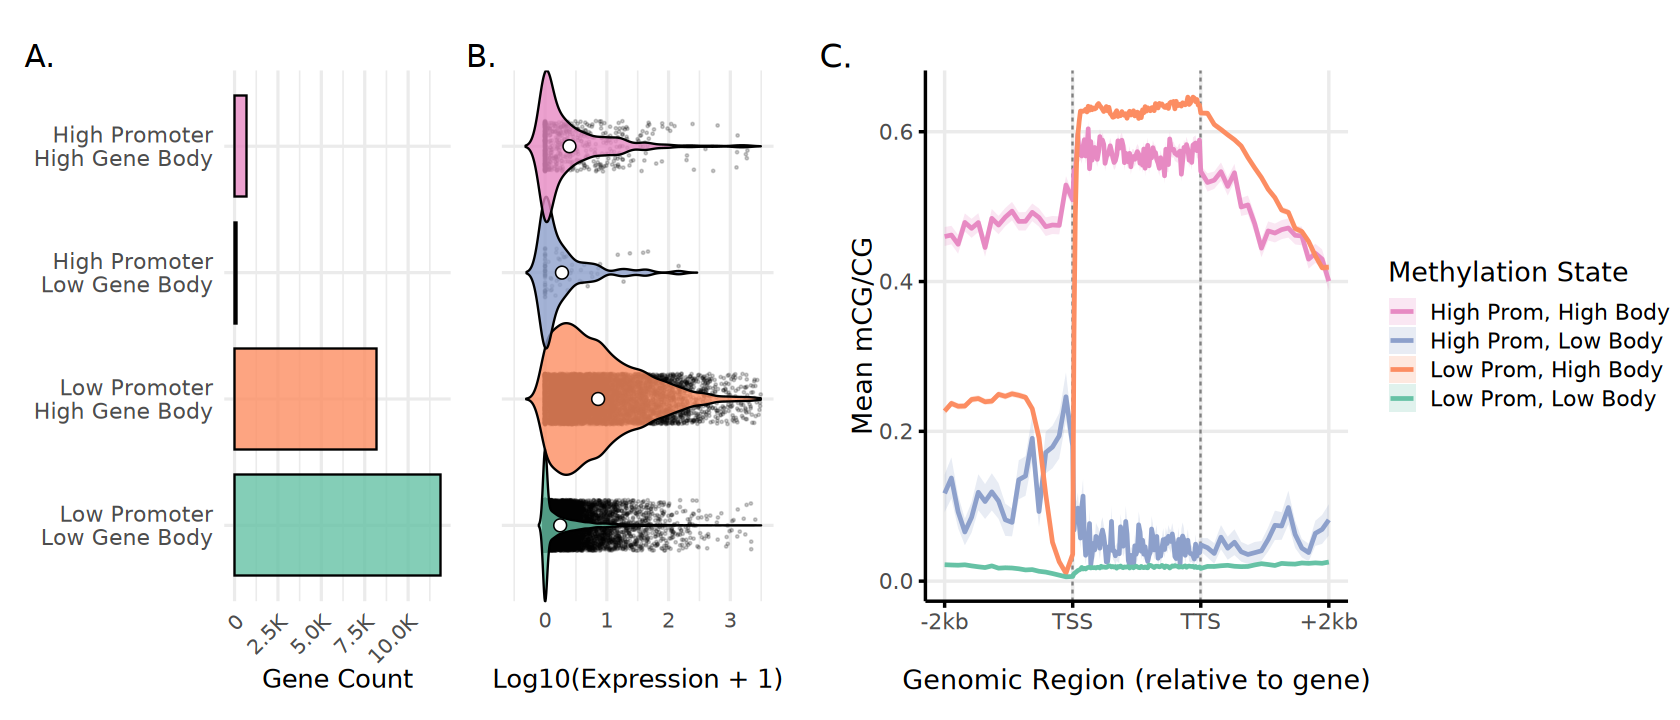

In [14]:
######################################################################
## 10: Combine Expression Panels with Metagene Profile
######################################################################

# Ensure output directory exists (safe if already created earlier)
out_fig_dir <- file.path("outputs", "figures")
dir.create(out_fig_dir, recursive = TRUE, showWarnings = FALSE)

# New top row: Gene count, violin, metagene profile
top_row <- plot_counts + plot_violin + plot_state_metagene +
  plot_layout(widths = c(1.5, 1.8, 2.8))

# Add a top spacer row to push panel letters down
combined_plot <- plot_spacer() / top_row +
  plot_layout(heights = c(-0.1, 1)) +
 plot_annotation(
  tag_levels = "A",
  tag_suffix = ".",
  theme = theme(
    plot.title = element_text(size = 18, hjust = 0.5, face = "bold")
  )
)

# Display in notebook
combined_plot

# Save alongside other figures
ggsave(
  filename = file.path(out_fig_dir, "Fig2.pdf"),
  plot     = combined_plot,
  width    = 16,
  height   = 5,
  units    = "in",
  device   = cairo_pdf,   # optional but good for publication PDFs
  bg       = "white"
)

In [15]:
######################################################################
## Reproducibility
######################################################################

cat("Date:", as.character(Sys.Date()), "\n")
cat("R version:", R.version.string, "\n")
cat("Platform:", R.version$platform, "\n")
cat("OS:", paste(Sys.info()[c("sysname","release")], collapse = " "), "\n\n")

pkgs <- c("bsseq","rtracklayer","GenomicRanges","tidyverse",
          "tximport","ppcor","ggplot2","patchwork")

cat("Key package versions:\n")
for (p in pkgs) {
  if (requireNamespace(p, quietly = TRUE)) {
    cat(sprintf("  %-14s %s\n", paste0(p, ":"), as.character(packageVersion(p))))
  } else {
    cat(sprintf("  %-14s %s\n", paste0(p, ":"), "not installed"))
  }
}

Date: 2026-07-31 
R version: R version 4.4.1 (2024-06-14) 
Platform: x86_64-conda-linux-gnu 
OS: Linux 5.15.0-185-generic 

Key package versions:
  bsseq:         1.40.0
  rtracklayer:   1.64.0
  GenomicRanges: 1.56.2
  tidyverse:     2.0.0
  tximport:      1.32.0
  ppcor:         1.1
  ggplot2:       3.5.2
  patchwork:     1.3.0
